In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [3]:
path = kagglehub.dataset_download("adhurimquku/ford-car-price-prediction")

In [4]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction
['ford.csv']


In [5]:
df = pd.read_csv(os.path.join(path, "ford.csv"))


In [6]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [7]:
df.head(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [8]:
df.shape

(17966, 9)

In [9]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [11]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [12]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

#**EDA**

<Axes: xlabel='price', ylabel='Count'>

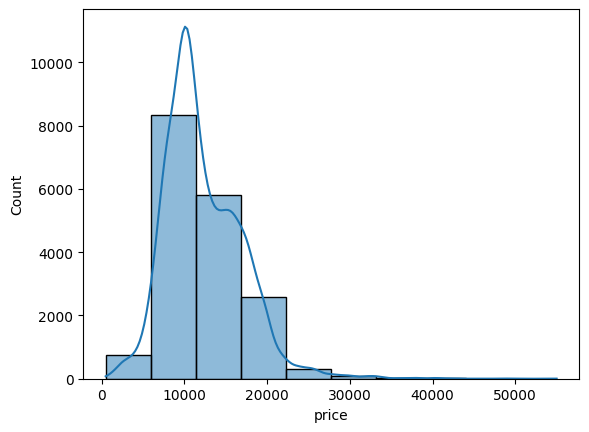

In [13]:
sns.histplot(df["price"],bins=10,kde=True)

<Axes: >

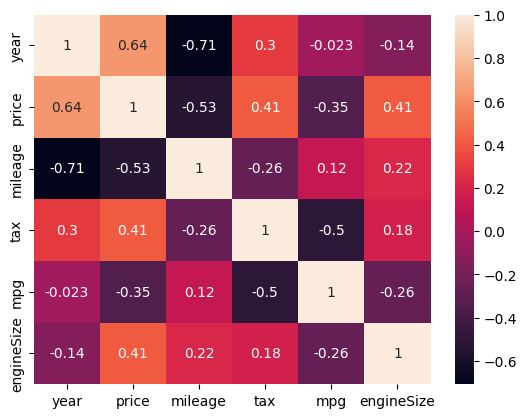

In [14]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

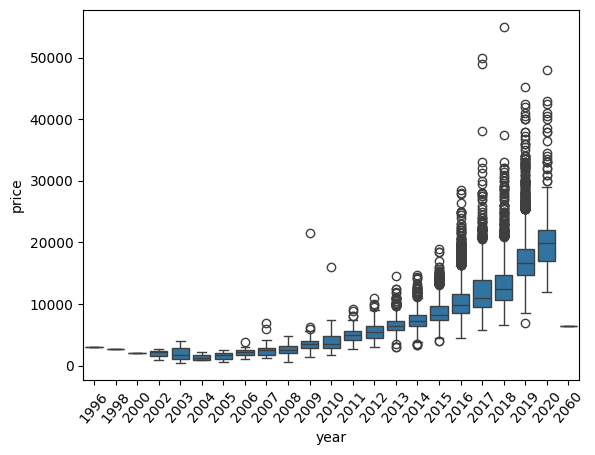

In [15]:
sns.boxplot(data=df, x="year", y="price")
plt.xticks(rotation=50)
plt.show()


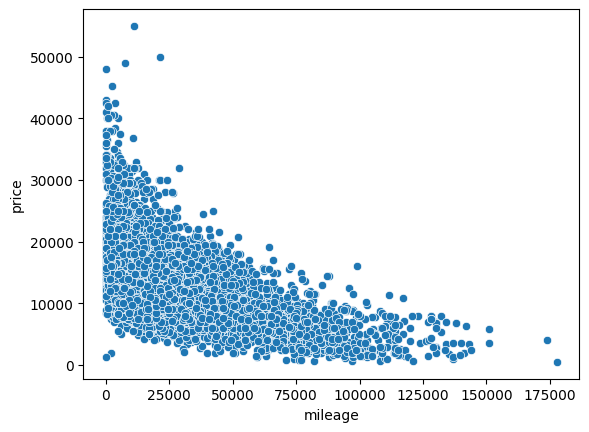

In [16]:
sns.scatterplot(data=df, x="mileage", y="price")
plt.show()

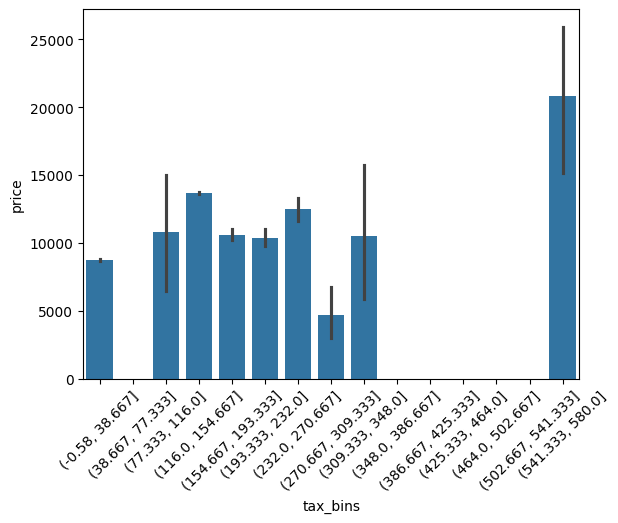

In [17]:
df["tax_bins"] = pd.cut(df["tax"], bins=15)

sns.barplot(data=df, x="tax_bins", y="price")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='engineSize', ylabel='price'>

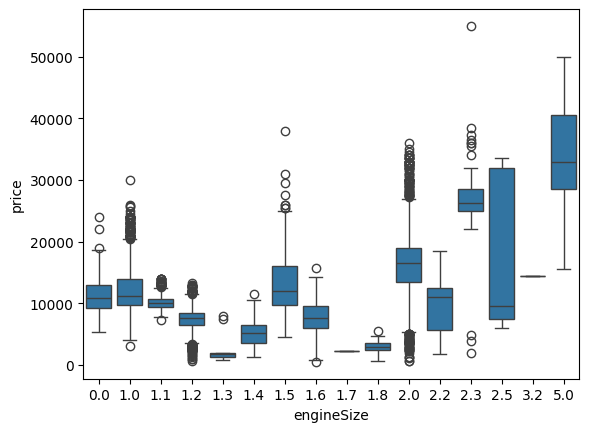

In [18]:
sns.boxplot(data=df,x="engineSize",y="price")

In [19]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'tax_bins'],
      dtype='object')

<Axes: xlabel='transmission', ylabel='price'>

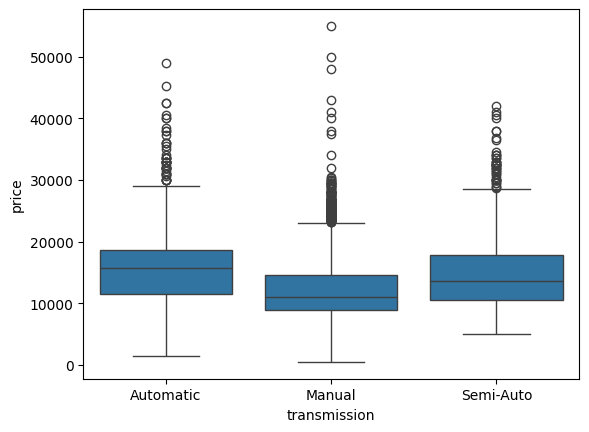

In [20]:
sns.boxplot(data=df,x="transmission",y="price")

<Axes: xlabel='fuelType', ylabel='price'>

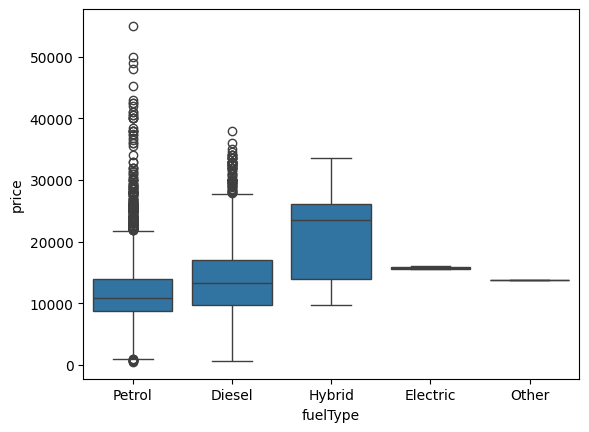

In [21]:
sns.boxplot(data=df,x="fuelType",y="price")

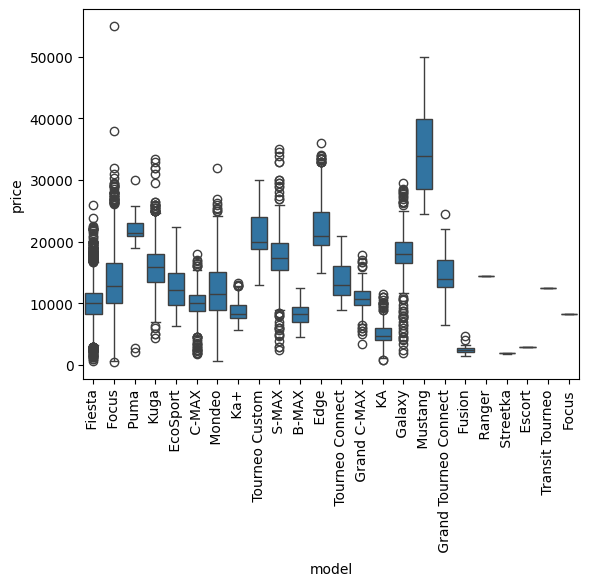

In [22]:
sns.boxplot(data=df,x="model",y="price")
plt.xticks(rotation=90)
plt.show()

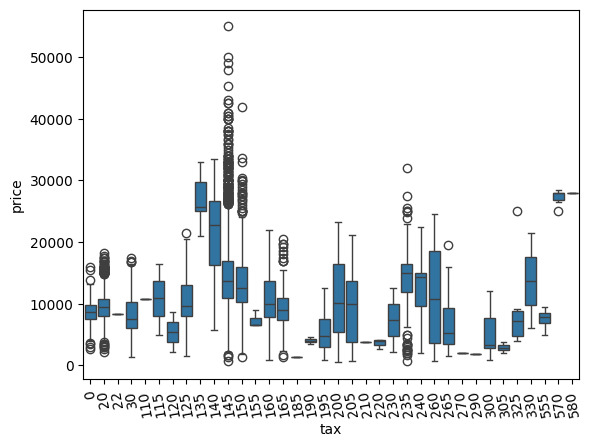

In [23]:
sns.boxplot(data=df,x="tax",y="price")
plt.xticks(rotation=100)
plt.show()

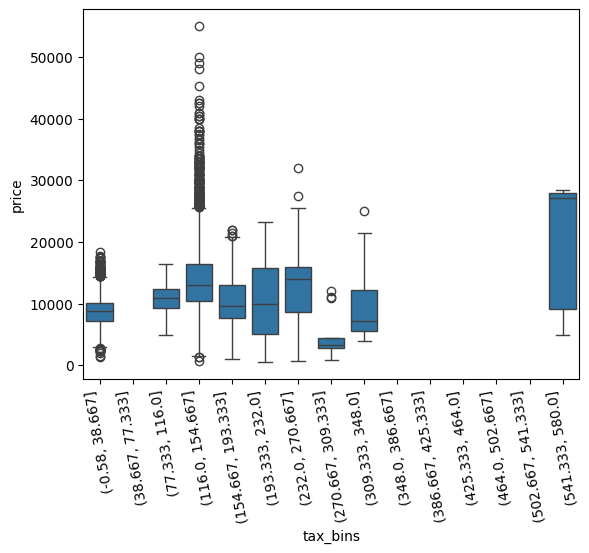

In [24]:
sns.boxplot(data=df,x="tax_bins",y="price")
plt.xticks(rotation=100)
plt.show()

In [25]:
x=df.drop(columns=["price"],axis=1)
y=df["price"]

In [26]:
x

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,tax_bins
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0,"(116.0, 154.667]"
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0,"(116.0, 154.667]"
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0,"(116.0, 154.667]"
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5,"(116.0, 154.667]"
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0,"(116.0, 154.667]"
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4,"(116.0, 154.667]"
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0,"(-0.58, 38.667]"
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6,"(-0.58, 38.667]"
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2,"(116.0, 154.667]"


In [27]:
x_one_encoding = pd.get_dummies(
    x,
    columns=["model", "transmission", "fuelType"],drop_first=True
)

In [28]:
x_one_encoding.head(2)

,year,mileage,tax,mpg,engineSize,tax_bins,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,"(116.0, 154.667]",False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,"(116.0, 154.667]",False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [29]:
# Separate features and target
X = df.drop(columns=["price"])
y = df["price"]

# Remove EDA-only bin column
X = X.drop(columns=["tax_bins"], errors="ignore")

# One-Hot Encoding
X_one_encoding = pd.get_dummies(
    X,
    columns=["model", "transmission", "fuelType"]
)

# Convert True/False to 1/0
X_one_encoding = X_one_encoding.astype(int)

# Check
print(X_one_encoding.head())
print(X_one_encoding.dtypes)

   year  mileage  tax  mpg  engineSize  model_ B-MAX  model_ C-MAX  \
0  2017    15944  150   57           1             0             0   
1  2018     9083  150   57           1             0             0   
2  2017    12456  150   57           1             0             0   
3  2019    10460  145   40           1             0             0   
4  2019     1482  145   48           1             0             0   

   model_ EcoSport  model_ Edge  model_ Escort  ...  model_ Transit Tourneo  \
0                0            0              0  ...                       0   
1                0            0              0  ...                       0   
2                0            0              0  ...                       0   
3                0            0              0  ...                       0   
4                0            0              0  ...                       0   

   model_Focus  transmission_Automatic  transmission_Manual  \
0            0                       1   

In [30]:
X_one_encoding.head(10)

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
5,2015,35432,145,47,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
6,2019,2029,145,50,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
7,2017,13054,145,54,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
8,2019,6894,145,42,2,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
9,2018,48141,145,61,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
label_encoder = LabelEncoder()

categorical_cols = ["model", "transmission", "fuelType"]

for col in categorical_cols:
    X[col] = label_encoder.fit_transform(X[col])

In [33]:
X.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0


In [34]:
X["model"].value_counts()

model
5     6557
6     4588
13    2225
2     1143
1      543
12     531
14     526
0      355
18     296
9      247
8      228
3      208
11     199
16      80
21      69
10      59
15      57
20      33
7       16
19       2
17       1
4        1
22       1
23       1
Name: count, dtype: int64

In [35]:
xlabel=X.copy()

In [36]:
xlabel["model"].value_counts()

model
5     6557
6     4588
13    2225
2     1143
1      543
12     531
14     526
0      355
18     296
9      247
8      228
3      208
11     199
16      80
21      69
10      59
15      57
20      33
7       16
19       2
17       1
4        1
22       1
23       1
Name: count, dtype: int64

In [37]:
xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
numerical_cols=["year","mileage","tax","mpg"]

In [40]:
scaler=StandardScaler()

In [41]:
X_one_encoding[numerical_cols] = scaler.fit_transform(
    X_one_encoding[numerical_cols]
)

In [42]:
 X_one_encoding

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.042122,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.042122,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.042122,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.721198,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.931045,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.029814,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.042122,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.945569,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.042122,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [43]:
xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [44]:
xlabel.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

In [45]:
xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']]= scaler.fit_transform(xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']])

In [46]:
xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,0.041351,-0.342172,0.688777,0.591358,-1.067312,0.113779
17962,-1.706810,-1.398088,0.041351,0.890398,0.688777,-1.343791,-0.020442,-0.811386
17963,-0.211477,-0.910349,0.041351,-0.839822,-1.454098,-1.505053,0.927668,0.576362
17964,1.034634,0.552866,0.041351,-0.942690,0.688777,0.510727,-0.020442,-0.348804


In [47]:
x_one_encoding

,year,mileage,tax,mpg,engineSize,tax_bins,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,"(116.0, 154.667]",False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,"(116.0, 154.667]",False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,12456,150,57.7,1.0,"(116.0, 154.667]",False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,2019,10460,145,40.3,1.5,"(116.0, 154.667]",False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,2019,1482,145,48.7,1.0,"(116.0, 154.667]",False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,"(116.0, 154.667]",False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,2014,40700,30,57.7,1.0,"(-0.58, 38.667]",False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,2015,7010,20,67.3,1.6,"(-0.58, 38.667]",False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,2018,5007,145,57.7,1.2,"(116.0, 154.667]",False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [48]:
xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,0.041351,-0.342172,0.688777,0.591358,-1.067312,0.113779
17962,-1.706810,-1.398088,0.041351,0.890398,0.688777,-1.343791,-0.020442,-0.811386
17963,-0.211477,-0.910349,0.041351,-0.839822,-1.454098,-1.505053,0.927668,0.576362
17964,1.034634,0.552866,0.041351,-0.942690,0.688777,0.510727,-0.020442,-0.348804


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X_one_encoding,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
model_1 = LinearRegression()

In [52]:
model_1.fit(X_train, y_train)

LinearRegression()

In [53]:
y_pred = model_1.predict(X_test)

In [54]:
y_pred

array([ 6866.3580764 ,  9347.6810129 ,  9362.18320785, ...,
       31454.95287518,  9781.20362786, 15253.49970894])

In [55]:
 y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
7731     22000
11655    13699
10536    24979
11885    10500
4032     19718
Name: price, Length: 3594, dtype: int64

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    xlabel,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
model_2= LinearRegression()

In [58]:
model_2.fit(X_train, y_train)

LinearRegression()

In [59]:
y_pred = model_2.predict(X_test)

In [60]:
y_pred

array([ 6152.07567671,  9374.39134399,  9464.92264335, ...,
       21787.05312508,  9776.43926374, 15806.24990719])

In [61]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
7731     22000
11655    13699
10536    24979
11885    10500
4032     19718
Name: price, Length: 3594, dtype: int64

In [62]:
r2=r2_score(y_test,y_pred)

In [63]:
r2

0.7365884288851352